## Ordinary Least Squares

Ordinary Least Squares (OLS) is a statistical method used in linear regression to predict a parameter by minimizing the sum of squared errors (SSE). It is the most common approach for linear regression problems.

$\widehat{Y}=\beta_0 + \beta_1 X_1 + \beta_2 X_2 + ... + \beta_k X_k$

$Y=\beta_0 + \beta_1 X_1 + \beta_2 X_2 + ... + \beta_k X_k + \epsilon$

OLS is a method used to obtain values for the coefficients (betas), where the error (epsilon) is minimal.

### Assumptions

1. Linearity

    Obviously, a linear regression model requires a linear relationship between predictor and response variables.

    Fixes:
    * Use a non-linear regression
    * Transform the relationship into a linear one

2. No Endogeneity

    It refers to a situation where an independent variable is correlated with the error. That usually happens due to omitted variable bias, which occurs when a relevant variable, that may influence the dependent and the independent variable, is omitted in the model, and therefore part of the error. Omitted variable bias is harder to fix.

    Fixes:
    * Avoid incorrect exclusion of relevant variables

3. Normality & Homoscedasticity of the error term

    $\epsilon \sim \mathcal{N}(0,\sigma^2)$

    1. The error is normally distributed with mean zero.

        For large enough samples the Central Limit Theorem applies for the error term too. The intercept assures that the mean error is zero.

    2. Homoscedasticity: equal variance of errors.

        Heteroscedasticity would lead to inconsistent predictions, due to inconsistent variance of the error.

        Fixes:
        * Check for omitted variable bias
        * Check for outliers
        * Log transformation

4. No Auto-Correlation

    No correlation between errors. A correlation between errors might occur when working with time series data.

    Fixes:
    * Use another model (like an autoregressive model)

5. No Multicollinearity

    Multicollinearity is observed when there is a strong correlation between two or more independent variables.

    Fixes:
    * Drop independent variables that are strongly correlated to other independent variables.
    * Transform them into one variable.

### Python Implementation

Implementing a basic linear regression model using the scikit-learn library...

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression

n = 100
k = 10

X, y = make_regression(n_samples=n, n_features=k, random_state=42)

df = pd.DataFrame(data=X, columns=[f"x_{i+1}" for i in range(k)])
df["y"] = y
df

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,y
0,0.150394,0.950424,-0.759133,-2.123896,-0.576904,-0.599393,-0.525755,-0.839722,0.341756,1.876171,-60.486955
1,1.088951,-0.715304,-0.471932,0.686260,0.679598,-1.867265,-1.612716,2.314659,0.064280,-1.077745,-0.091994
2,-0.714351,-1.191303,0.293072,-0.680025,0.656554,0.346448,0.232254,0.250493,1.865775,0.473833,-76.947132
3,0.404051,0.257550,-0.161286,-0.342715,-0.074446,-0.420645,-0.802277,-1.415371,1.886186,0.174578,-38.245170
4,0.606010,-2.081929,-1.556629,-0.704344,1.696456,1.049009,-1.408461,-0.522723,-1.280429,1.754794,-1.831243
...,...,...,...,...,...,...,...,...,...,...,...
95,-1.889541,-1.583903,-0.446183,0.840644,0.760415,-0.681052,-0.652624,0.128104,-0.452306,-2.423879,-355.524645
96,0.234215,0.984322,-0.034685,-1.004141,-0.213989,-0.918652,-0.767798,-1.344451,1.550500,-0.998354,-123.280766
97,0.129221,0.481009,2.445752,0.279969,0.223884,-0.055585,-1.125489,0.654366,0.109395,0.725767,61.966355
98,0.279022,-0.446434,-0.095296,0.249384,0.194090,0.219150,1.577453,-0.307778,0.607897,0.186609,148.783164


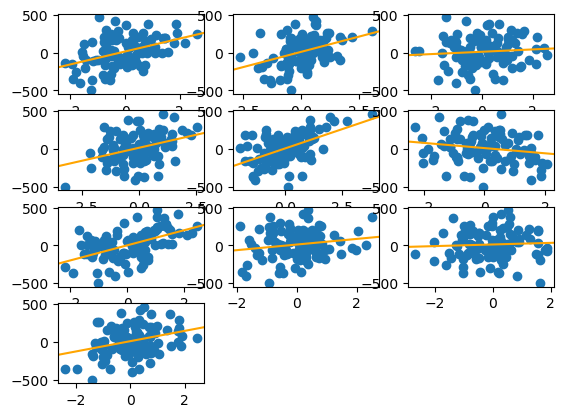

In [64]:
cols = 3
rows = int(np.ceil(k / 3))

for i in range(k):
    plt.subplot(rows, cols, i+1)
    plt.scatter(X[:,i], y)
    weight, bias = np.polyfit(X[:,i], y, 1)
    plt.axline(xy1=(0, bias), slope=weight, c="orange")

<Axes: title={'center': 'Correlation Matrix'}>

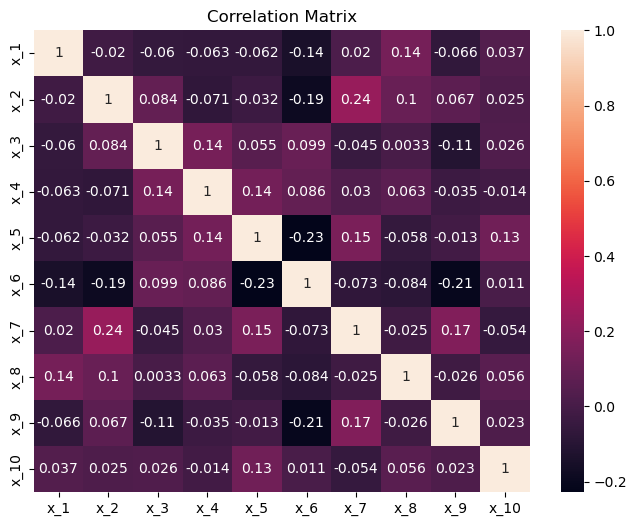

In [65]:
import seaborn as sns

corr_mat = df.drop("y", axis=1).corr()
plt.figure(figsize=(8, 6))
plt.title("Correlation Matrix")
sns.heatmap(corr_mat, annot=True)

In [66]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def r2_adj(r2, n=n, k=k):
    return 1 - np.divide((1-r2) * (n-1), n - k - 1)

model = LinearRegression()
model.fit(X, y)
y_preds = model.predict(X)

print(f"""MAE: {mean_absolute_error(y, y_preds)}
MSE: {mean_squared_error(y, y_preds)}
R2: {r2_score(y, y_preds)}
adjusted R2: {r2_adj(r2_score(y, y_preds))}
Intercept: {model.intercept_}
Coefficients: {model.coef_}

{n} observations
{k} features
""")

MAE: 1.085709300241433e-13
MSE: 1.9518312061340364e-26
R2: 1.0
adjusted R2: 1.0
Intercept: 1.7763568394002505e-15
Coefficients: [93.62122462 70.90605195  3.15861448 63.64302495 87.09691237 10.45678403
 70.64757265 16.74825823  5.19712837 54.12963353]

100 observations
10 features



**Strengths of OLS**:

1. Simplicity: Easy to implement and to interpret.
2. Efficiency: Closed-form solution; no iterative optimization.
3. Widely applicable.

**Limitations of OLS**:

1. Sensitive to outliers.
2. Multicollinearity: Strong correlation between features reduces the reliability of the model's predictions.
3. Limited to linearity: Cannot capture non-linear patterns.